# Surrogate Model Stress Test (qubit_TransmonCross_cap_matrix)
## Uniform Random Points + NN-Distance Binning

We are going to generate thousands of uniformly random Quantum Metal parameter sets inside the training data cloud (convex hull, so pure interpolation -- no extrapolation). Then well run them through the surrogate model to predict the Hamiltonian, and save 100 of them, evenly spread across 10 bins of distance to the nearest training point, to simulate in the EM simulator.

## Configuration

In [1]:
from parameters_surrogate import *

## Library

In [2]:
import os, gc, math, time
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow.keras.models import load_model

In [3]:
## imports that come up later
from scipy.spatial import Delaunay
import platform
from matplotlib.colors import LinearSegmentedColormap
import json
import matplotlib.patches as mpatches

## Load Dataset & Surrogate Model

In [4]:
def load_scaled_split(kind, split):
    return np.load(f'{DATA_DIR}/npy/{split}_{kind}_encoding_scaled.npy', allow_pickle=True)

X_train = load_scaled_split('linear', 'y_train')
X_val   = load_scaled_split('linear', 'y_val')
X_test  = load_scaled_split('linear', 'y_test')

y_train = load_scaled_split('linear', 'x_train')
y_val   = load_scaled_split('linear', 'x_val')
y_test  = load_scaled_split('linear', 'x_test')

with open(str(Path(METADATA_DIR) / 'X_names'), 'r') as f:
    Hamiltonian_column_names = f.read().splitlines()

qiskit_param_names = np.load(str(Path(METADATA_DIR) / 'y_columns.npy'), allow_pickle=True).astype(str).tolist()

print(f'Inputs (Qiskit params):  {X_train.shape[1]} columns: {qiskit_param_names}')
print(f'Outputs (Capacitance):   {y_train.shape[1]} columns: {Hamiltonian_column_names}')
print(f'Training samples: {len(X_train)}, Test samples: {len(X_test)}')

Inputs (Qiskit params):  3 columns: ['design_options.connection_pads.readout.claw_length', 'design_options.connection_pads.readout.ground_spacing', 'design_options.cross_length']
Outputs (Capacitance):   2 columns: ['qubit_frequency_GHz', 'anharmonicity_MHz']
Training samples: 1353, Test samples: 291


In [5]:
tf.keras.backend.clear_session()
gc.collect()

chosen_path = str(Path(MODEL_DIR) / 'best_keras_model_model2_surrogate.keras')
with tf.device('/CPU:0'):
    surrogate = load_model(chosen_path, compile=False)

print(f'Loaded surrogate: {chosen_path}')
surrogate.summary()

Loaded surrogate: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/model/best_keras_model_model2_surrogate.keras


I0000 00:00:1778118097.379235    1636 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38389 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe MIG 4g.40gb, pci bus id: 0000:06:00.0, compute capability: 8.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc0 (Dense)                     │ (None, 736)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_relu0 (LeakyReLU)         │ (None, 736)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout0 (Dropout)              │ (None, 736)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │         1,474 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,418 (17.26 KB)

 Trainable params: 4,418 (17.26 KB)

 Non-trainable params: 0 (0.00 B)

## Load Scalers for Unscaling

In [6]:
## load all scalers so we can go back and forth between scaled and unscaled
qiskit_scalers = {}
for name in qiskit_param_names:
    qiskit_scalers[name] = joblib.load(f'{SCALERS_DIR}/scaler_y_linear_{name}.save')

Hamiltonian_scalers = {}
for name in Hamiltonian_column_names:
    Hamiltonian_scalers[name] = joblib.load(f'{SCALERS_DIR}/scaler_X_linear_{name}.save')

def unscale_qiskit(X_scaled):
    """Unscale Quantum Metal params from [0,1] back to real values."""
    X_out = X_scaled.copy()
    for j, name in enumerate(qiskit_param_names):
        X_out[:, j] = qiskit_scalers[name].inverse_transform(X_out[:, j:j+1]).ravel()
    return X_out

def scale_qiskit(X_real):
    """Scale real Quantum Metal params to [0,1]."""
    X_out = X_real.copy()
    for j, name in enumerate(qiskit_param_names):
        X_out[:, j] = qiskit_scalers[name].transform(X_out[:, j:j+1]).ravel()
    return X_out

def unscale_Hamiltonian(y_scaled):
    """Unscale capacitance predictions back to real values."""
    y_out = y_scaled.copy()
    for j, name in enumerate(Hamiltonian_column_names):
        y_out[:, j] = Hamiltonian_scalers[name].inverse_transform(y_out[:, j:j+1]).ravel()
    return y_out

## quick test
X_test_unscaled = unscale_qiskit(np.asarray(X_test))
print('Unscaled test set param ranges:')
for j, name in enumerate(qiskit_param_names):
    short = name.replace('design_options.', '')
    vals = X_test_unscaled[:, j]
    print(f'  {short:30s}  min={vals.min()}  max={vals.max()}  mean={vals.mean()}')

Unscaled test set param ranges:
  connection_pads.readout.claw_length  min=7e-05  max=0.00037  mean=0.00017103092783505154
  connection_pads.readout.ground_spacing  min=4.1e-06  max=1e-05  mean=7.091752577319587e-06
  cross_length                    min=9e-05  max=0.00042  mean=0.0002902405498281787


## Identify Integer vs Continuous Parameters

We need to know which parameters are integers (like finger_count) so we can
use different noise for those and Gaussian noise for the continuous ones.

In [7]:
## see if all of the training sets are integers for a specific column
X_all_unscaled = unscale_qiskit(np.vstack([X_train, X_val, X_test]).astype('float64'))

is_integer_param = []
integer_unique_vals = {}  
for j, name in enumerate(qiskit_param_names):
    vals = X_all_unscaled[:, j]
    all_integer = np.allclose(vals, np.round(vals))
    is_integer_param.append(all_integer)
    if all_integer:
        integer_unique_vals[j] = sorted(set(np.round(vals).astype(int)))
        print(f'  {name}: INTEGER - unique values: {integer_unique_vals[j]}')
    else:
        print(f'  {name}: CONTINUOUS - range [{vals.min()}, {vals.max()}]')

## figure out the range for each parameter
X_train_unscaled = unscale_qiskit(np.asarray(X_train).astype('float64'))
param_ranges = X_train_unscaled.max(axis=0) - X_train_unscaled.min(axis=0)
print(f'\nParameter ranges: {param_ranges}')

  design_options.connection_pads.readout.claw_length: CONTINUOUS - range [7e-05, 0.00039999999999999996]
  design_options.connection_pads.readout.ground_spacing: CONTINUOUS - range [4.1e-06, 1e-05]
  design_options.cross_length: CONTINUOUS - range [9e-05, 0.00042]

Parameter ranges: [3.3e-04 5.9e-06 3.3e-04]


In [8]:
max(X_train_unscaled[:,0])

0.00039999999999999996

## Generate Random Points Inside the Training Cloud

Instead of centering gaussians on test points, scatter thousands of uniformly random points inside the convex hull of the training data (pure interpolation, no extrapolation), with the same physical-validity checks as before. Then pick 100 of them evenly spread across 10 bins of distance to the nearest training point.

In [9]:
N_RANDOM_POINTS = 50000     ## how many uniformrandom points to generate before subselecting
N_TO_SELECT     = 100        ## total points to send to Firas for EM simulator simulation
N_BINS          = 10        ## number of NNdistance bins to split points into
N_PER_BIN       = N_TO_SELECT // N_BINS  ## points to randomly draw from each bin

np.random.seed(37) ## set this to keep the 'random' selections the same on different trials

def generate_random_bounded(n_points, param_ranges):
    ## make uniformly random unscaled points INSIDE the training cloud
    ## (convex hull of the training set) so we get pure interpolation,
    ## no extrapolation. same physicalvalidity checks as
    ## generate_augmented_bounded so everything we hand to Firas is
    ## actually simulatable in EM simulator.

    '''constraints needed to check validity of a random design'''
    ## singlevalued SQuADDS params we do not train on ##
    claw_gap = 5.1 / 1e6 ## in meters
    cross_gap = 30 / 1e6 ## in meters

    ## boundaries of the training space ##
    max_claw_length = max(X_train_unscaled[:,0])
    min_claw_length = min(X_train_unscaled[:,0])
    max_ground_spacing = max(X_train_unscaled[:,1])
    min_ground_spacing = min(X_train_unscaled[:,1])
    max_cross_length = max(X_train_unscaled[:,2])
    min_cross_length = min(X_train_unscaled[:,2])

    ## convex hull of the training cloud used to reject extrapolating draws ##
    hull = Delaunay(X_train_unscaled)

    ''' iterate until we have n_points valid random designs '''
    out = np.zeros((n_points, 3))
    for k in range(n_points):

        valid_design = False

        while valid_design == False: ## don't break until we have a valid design

            ## uniformly random inside the training box for each param
            claw_length    = np.random.uniform(min_claw_length, max_claw_length)
            ground_spacing = np.random.uniform(min_ground_spacing, max_ground_spacing)
            cross_length   = np.random.uniform(min_cross_length, max_cross_length)

            '''
            constraints are as follows:
            1) random draws are already inside the training bounding box from the np.random.uniform bounds
            2) ensure the coupling claw does not physically overlap with the transmon cross
            3) reject points outside the convex hull of the training cloud
               (pure interpolation only, no extrapolation)
            '''
            in_hull = hull.find_simplex([claw_length, ground_spacing, cross_length]) >= 0
            if ((claw_length + 2*claw_gap) < (ground_spacing + cross_length)) and in_hull: ## 2) and 3)
                valid_design = True

        out[k] = [claw_length, ground_spacing, cross_length]

    return out

print(f'Will generate {N_RANDOM_POINTS} valid random points inside the training data cloud')
print(f'Will pick {N_TO_SELECT} of them ({N_PER_BIN} per bin) evenly across {N_BINS} NN-distance bins')

Will generate 50000 valid random points inside the training data cloud
Will pick 100 of them (10 per bin) evenly across 10 NN-distance bins


## Run the random points through the surrogate and compute NN distances

In [10]:
## generate the random points and run them through the surrogate
random_unscaled = generate_random_bounded(N_RANDOM_POINTS, param_ranges)

## scale to [0,1] for the surrogate
random_scaled = scale_qiskit(random_unscaled)
random_scaled_f32 = random_scaled.astype('float32')

## surrogate inference timing for the paper speedup claim.
## we warm up the model (tf.function tracing, XLA compile) before timing.
## reports batch throughput AND singlesample call time.

print(f'Running {len(random_scaled_f32)} samples through surrogate...')

with tf.device('/CPU:0'):
    for _ in range(5):
        _ = surrogate.predict(random_scaled_f32[:1], verbose=0)
        _ = surrogate.predict(random_scaled_f32[:64], verbose=0)

    ## the full run we also use downstream
    t0 = time.time()
    predicted_Hamiltonian_scaled = surrogate.predict(random_scaled_f32, verbose=0)
    t1 = time.time()
    total_time = t1 - t0
    per_sample_us = (total_time / len(random_scaled_f32)) * 1e6

    ## singlesample call time (what matters for a oneoff design query)
    single_times_ms = []
    for _ in range(50):
        ts = time.perf_counter()
        _ = surrogate.predict(random_scaled_f32[:1], verbose=0)
        te = time.perf_counter()
        single_times_ms.append((te - ts) * 1000.0)
    single_mean_ms = float(np.mean(single_times_ms))
    single_std_ms  = float(np.std(single_times_ms))

print(f'  Batch ({len(random_scaled_f32)} samples): {total_time:.3f} s total, {per_sample_us:.1f} us/sample')
print(f'  Single-sample call:                    {single_mean_ms:.3f} +/- {single_std_ms:.3f} ms')
print(f'  Hardware: {platform.processor() or platform.machine()} | {platform.system()} {platform.release()}')

## speedup vs EM simulator Q3D (2 min / sample)
ansys_ms_per_sample = 2.0 * 60.0 * 1000.0  ## 120,000 ms
speedup_batch_per_sample = ansys_ms_per_sample / (per_sample_us / 1000.0)
speedup_single_call = ansys_ms_per_sample / single_mean_ms
print(f'  Speedup vs EM simulator (batch per-sample): {speedup_batch_per_sample:.2e}')
print(f'  Speedup vs EM simulator (single call):      {speedup_single_call:.2e}')

## unscale the predictions back to real values
predicted_Hamiltonian_unscaled = unscale_Hamiltonian(predicted_Hamiltonian_scaled)

/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Running 50000 samples through surrogate...


I0000 00:00:1778118109.267816 1269494 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Batch (50000 samples): 2.543 s total, 50.9 us/sample
  Single-sample call:                    751.510 +/- 110.380 ms
  Hardware: x86_64 | Linux 6.3.12-200.fc38.x86_64
  Speedup vs EM simulator (batch per-sample): 2.36e+06
  Speedup vs EM simulator (single call):      1.60e+02


In [11]:

## nearesttrainingpoint distance for every random sample.
## we work in the scaled [0,1] parameter space so each of the 3 qiskit
## metal params contributes equally (otherwise the param with the largest
## raw range would dominate the distance). Euclidean distance is used
## (rMS would give an identical ranking, just divided by sqrt(n_params)).

X_train_scaled = np.asarray(X_train).astype('float64')  ## already in [0,1]

def nearest_train_distance(points_scaled, train_scaled=X_train_scaled):
    ## euclidean distance from each point to its closest training sample,
    ## computed in the scaled [0,1] space.
    diff = points_scaled[:, None, :] - train_scaled[None, :, :]
    d = np.sqrt((diff ** 2).sum(axis=-1))
    return d.min(axis=1)

nn_dist = nearest_train_distance(random_scaled.astype('float64'))

print(f'NN-dist across {N_RANDOM_POINTS} random points:')
print(f'  min={nn_dist.min():.4f}  median={np.median(nn_dist):.4f}  mean={nn_dist.mean():.4f}  max={nn_dist.max():.4f}')

## store everything in an all_resultsstyle dict so any downstream cell that
## expected all_results[key] still works (just a single 'uniform' entry now
## instead of one entry per sigma)
all_results = {'uniform': {
    'augmented_unscaled': random_unscaled,
    'augmented_scaled':   random_scaled,
    'predicted_Hamiltonian_scaled':   predicted_Hamiltonian_scaled,
    'predicted_Hamiltonian_unscaled': predicted_Hamiltonian_unscaled,
    'nn_dist':        nn_dist,
    'total_time':     total_time,
    'per_sample_us':  per_sample_us,
}}

NN-dist across 50000 random points:
  min=0.0023  median=0.1283  mean=0.1492  max=0.4723


## Pick 100 Candidates Evenly Across 10 NN-Distance Bins

Split the NN-distance range into 10 equal-width bins, from 'closest to training data' at bin 1 to 'farthest' at bin 10, and randomly draw 9 points from each bin so Firas gets a clean sweep across extrapolation difficulty.

In [12]:
## equalwidth bins across the NNdistance range so the 3 bins correspond
## to 'close to training', 'medium', and 'far' in a geometric sense
bin_edges = np.linspace(nn_dist.min(), nn_dist.max(), N_BINS + 1)
print(f'Bin edges (scaled [0,1] NN distance): {bin_edges}')

selected_idx = []
selected_bin = []
for b in range(N_BINS):
    lo, hi = bin_edges[b], bin_edges[b + 1]
    ## include the top edge for the last bin so we don't drop the max point
    in_bin = (nn_dist >= lo) & (nn_dist <= hi if b == N_BINS - 1 else nn_dist < hi)
    bin_indices = np.where(in_bin)[0]
    print(f'  Bin {b+1}  [{lo:.4f}, {hi:.4f}]  contains {len(bin_indices)} points')
    if len(bin_indices) < N_PER_BIN:
        raise ValueError(
            f'Bin {b+1} only has {len(bin_indices)} points, need {N_PER_BIN}. '
            f'Increase N_RANDOM_POINTS.'
        )
    ## randomly pick N_PER_BIN from this bin
    chosen = np.random.choice(bin_indices, size=N_PER_BIN, replace=False)
    selected_idx.extend(chosen.tolist())
    selected_bin.extend([b + 1] * N_PER_BIN)

selected_idx = np.array(selected_idx)
selected_bin = np.array(selected_bin)

## pull out the params / predictions / nndist for the selected points
selected_params_unscaled  = random_unscaled[selected_idx]
selected_params_scaled    = random_scaled[selected_idx]
selected_pred_Hamiltonian = predicted_Hamiltonian_unscaled[selected_idx]
selected_nn_dist          = nn_dist[selected_idx]

print(f'\nSelected {len(selected_idx)} points total ({N_PER_BIN} per bin)')

Bin edges (scaled [0,1] NN distance): [0.00233621 0.04933074 0.09632526 0.14331979 0.19031431 0.23730884
 0.28430336 0.33129788 0.37829241 0.42528693 0.47228146]
  Bin 1  [0.0023, 0.0493]  contains 11031 points
  Bin 2  [0.0493, 0.0963]  contains 10121 points
  Bin 3  [0.0963, 0.1433]  contains 5653 points
  Bin 4  [0.1433, 0.1903]  contains 5433 points
  Bin 5  [0.1903, 0.2373]  contains 5211 points
  Bin 6  [0.2373, 0.2843]  contains 5051 points
  Bin 7  [0.2843, 0.3313]  contains 4821 points
  Bin 8  [0.3313, 0.3783]  contains 2410 points
  Bin 9  [0.3783, 0.4253]  contains 241 points
  Bin 10  [0.4253, 0.4723]  contains 28 points

Selected 100 points total (10 per bin)


In [13]:
## print the candidates, grouped by bin
for b in range(N_BINS):
    in_bin = selected_bin == (b + 1)
    lo, hi = bin_edges[b], bin_edges[b + 1]
    print(f'\n{"-"*80}')
    print(f'BIN {b+1}  NN-distance in [{lo:.4f}, {hi:.4f}]  -- {in_bin.sum()} samples')
    print(f'{"-"*80}')

    bin_positions = np.where(in_bin)[0]
    for rank, local_i in enumerate(bin_positions):
        print(f'\n--- Sample {rank+1} in bin {b+1} (nn_dist={selected_nn_dist[local_i]:.4f}) ---')

        print(f'  Quantum Metal params (for EM simulator simulation):')
        for j, name in enumerate(qiskit_param_names):
            short = name.replace('design_options.', '')
            val = selected_params_unscaled[local_i, j]
            if is_integer_param[j]:
                print(f'    {short:30s}  {int(round(val))}')
            else:
                print(f'    {short:30s}  {val}')

        print(f'  Surrogate predicted Hamiltonian:')
        for j, name in enumerate(Hamiltonian_column_names):
            short = name.split('.')[-1] if '.' in name else name
            print(f'    {short:30s}  {selected_pred_Hamiltonian[local_i, j]:.6e}')


--------------------------------------------------------------------------------
BIN 1  NN-distance in [0.0023, 0.0493]  -- 10 samples
--------------------------------------------------------------------------------

--- Sample 1 in bin 1 (nn_dist=0.0475) ---
  Quantum Metal params (for EM simulator simulation):
    connection_pads.readout.claw_length  0.00033769352817143554
    connection_pads.readout.ground_spacing  9.724500959994953e-06
    cross_length                    0.0003982332970893718
  Surrogate predicted Hamiltonian:
    qubit_frequency_GHz             3.323267e+00
    anharmonicity_MHz               -9.532227e+01

--- Sample 2 in bin 1 (nn_dist=0.0375) ---
  Quantum Metal params (for EM simulator simulation):
    connection_pads.readout.claw_length  0.0001538687962433939
    connection_pads.readout.ground_spacing  8.914937409555788e-06
    cross_length                    0.00031442671665412014
  Surrogate predicted Hamiltonian:
    qubit_frequency_GHz             3.7236

## Exporting Candidates for Firas to Simulate

In [14]:
## save a CSV with all 100 random candidates to simulate in EM simulator
export_rows = []
for i in range(len(selected_idx)):
    row = {
        'sample_number': i + 1,
        'nn_bin': int(selected_bin[i]),
        'nn_distance_scaled': selected_nn_dist[i],
        'surrogate_inference_us': per_sample_us,
    }
    ## qiskit metal params
    for j, name in enumerate(qiskit_param_names):
        val = selected_params_unscaled[i, j]
        row[f'{name}'] = val
    ## surrogate predicted hamiltonian params
    for j, name in enumerate(Hamiltonian_column_names):
        short = name.split('.')[-1] if '.' in name else name
        row[f'surrogate_pred_{short}'] = selected_pred_Hamiltonian[i, j]
    export_rows.append(row)

df_export = pd.DataFrame(export_rows)
csv_path = str(Path(RESULTS_DIR) / 'validation/random_candidates_for_em_sim_validation_nn_bins.csv')
df_export.to_csv(csv_path, index=False, float_format='%.6g')
print(f'Saved {len(df_export)} random candidates to {csv_path} ({N_PER_BIN} per bin x {N_BINS} bins)')
display(df_export)

Saved 100 random candidates to /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/validation/random_candidates_for_em_sim_validation_nn_bins.csv (10 per bin x 10 bins)


,sample_number,nn_bin,nn_distance_scaled,surrogate_inference_us,design_options.connection_pads.readout.claw_length,design_options.connection_pads.readout.ground_spacing,design_options.cross_length,surrogate_pred_qubit_frequency_GHz,surrogate_pred_anharmonicity_MHz
0,1,1,0.047517,50.8634,0.000338,0.000010,0.000398,3.323267,-95.322273
1,2,1,0.037504,50.8634,0.000154,0.000009,0.000314,3.723613,-121.708664
2,3,1,0.024609,50.8634,0.000301,0.000009,0.000327,3.654558,-116.949127
3,4,1,0.044148,50.8634,0.000163,0.000009,0.000323,3.677107,-118.471519
4,5,1,0.025659,50.8634,0.000088,0.000004,0.000235,4.400198,-174.165268
...,...,...,...,...,...,...,...,...,...
95,96,10,0.452956,50.8634,0.000388,0.000007,0.000414,3.153938,-83.761604
96,97,10,0.454214,50.8634,0.000381,0.000007,0.000416,3.144475,-83.097466
97,98,10,0.435537,50.8634,0.000379,0.000007,0.000408,3.187585,-86.106339
98,99,10,0.431391,50.8634,0.000366,0.000007,0.000417,3.138318,-82.668564


In [15]:
## summary of what was exported
print(f'Total candidates: {len(df_export)}')
print(f'  {N_PER_BIN} random samples per NN-distance bin')
print(f'  {N_BINS} bins, equal-width in scaled [0,1] NN-distance space')
print(f'  Bin edges: {bin_edges}')
print(f'\nThese are uniformly RANDOM samples across the training param space')
print(f'(with the same physical-validity constraint as before), so the EM simulator')
print(f'results will give an unbiased picture of surrogate accuracy vs distance')
print(f'to the nearest training point.')

Total candidates for user: 100
  10 random samples per NN-distance bin
  10 bins, equal-width in scaled [0,1] NN-distance space
  Bin edges: [0.00233621 0.04933074 0.09632526 0.14331979 0.19031431 0.23730884
 0.28430336 0.33129788 0.37829241 0.42528693 0.47228146]

These are uniformly RANDOM samples across the training param space
(with the same physical-validity constraint as before), so the EM simulator
results will give an unbiased picture of surrogate accuracy vs distance
to the nearest training point.


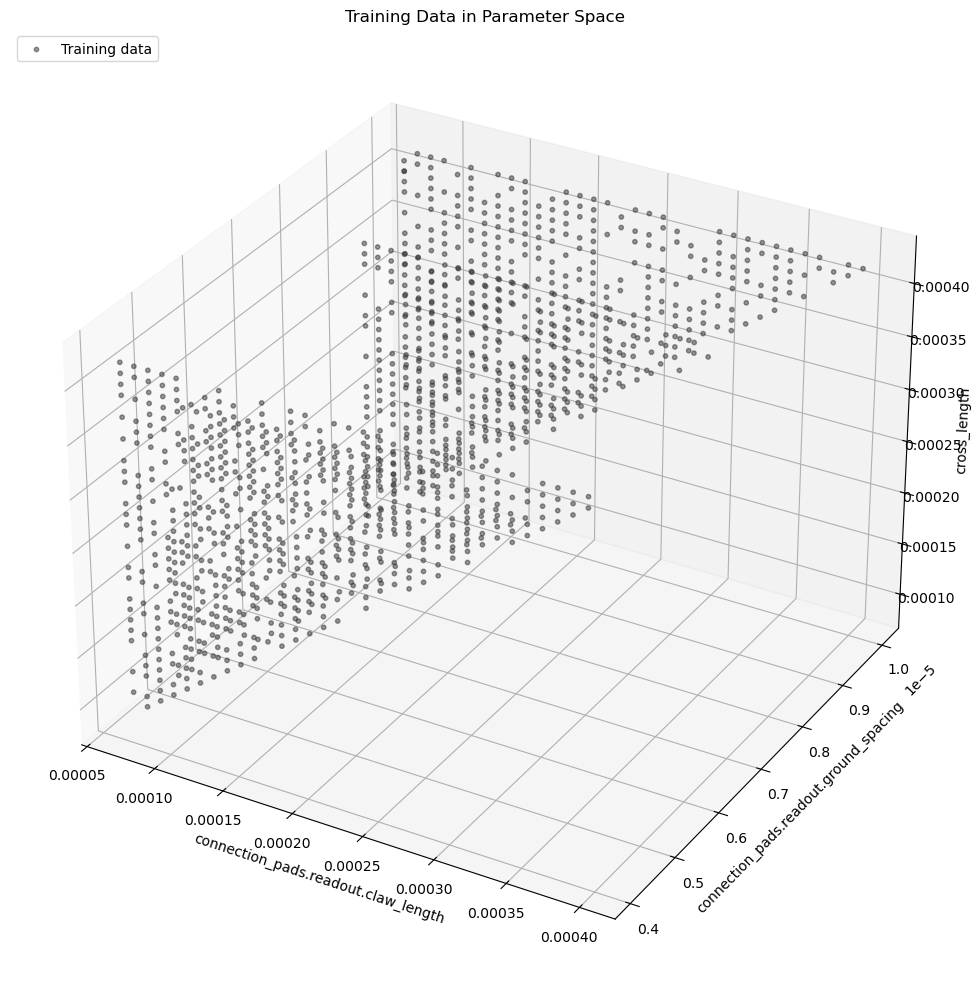

In [16]:
cont_indices = [j for j in range(len(qiskit_param_names)) if not is_integer_param[j]]
if len(cont_indices) >= 3:
    p0, p1, p2 = cont_indices[0], cont_indices[1], cont_indices[2]
else:
    p0, p1, p2 = 0, 1, 2

axis_names = [
    qiskit_param_names[p0].replace('design_options.', ''),
    qiskit_param_names[p1].replace('design_options.', ''),
    qiskit_param_names[p2].replace('design_options.', ''),
]

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_train_unscaled[:, p0], X_train_unscaled[:, p1], X_train_unscaled[:, p2],
           c='#333333', s=10, alpha=0.5, label='Training data')

ax.set_xlabel(axis_names[0])
ax.set_ylabel(axis_names[1])
ax.set_zlabel(axis_names[2])
ax.set_title('Training Data in Parameter Space')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'training_data_3d.pdf'))
plt.show()

In [17]:
hull_check = Delaunay(X_train_unscaled)
inside = hull_check.find_simplex(selected_params_unscaled) >= 0
print(f'{inside.sum()}/{len(selected_params_unscaled)} selected points are inside the convex hull')
print(f'min NN distance: {selected_nn_dist.min():.4f}')
print(f'max NN distance: {selected_nn_dist.max():.4f}  <- this is your "most isolated interior point"')

100/100 selected points are inside the convex hull
min NN distance: 0.0231
max NN distance: 0.4723  <- this is your "most isolated interior point"


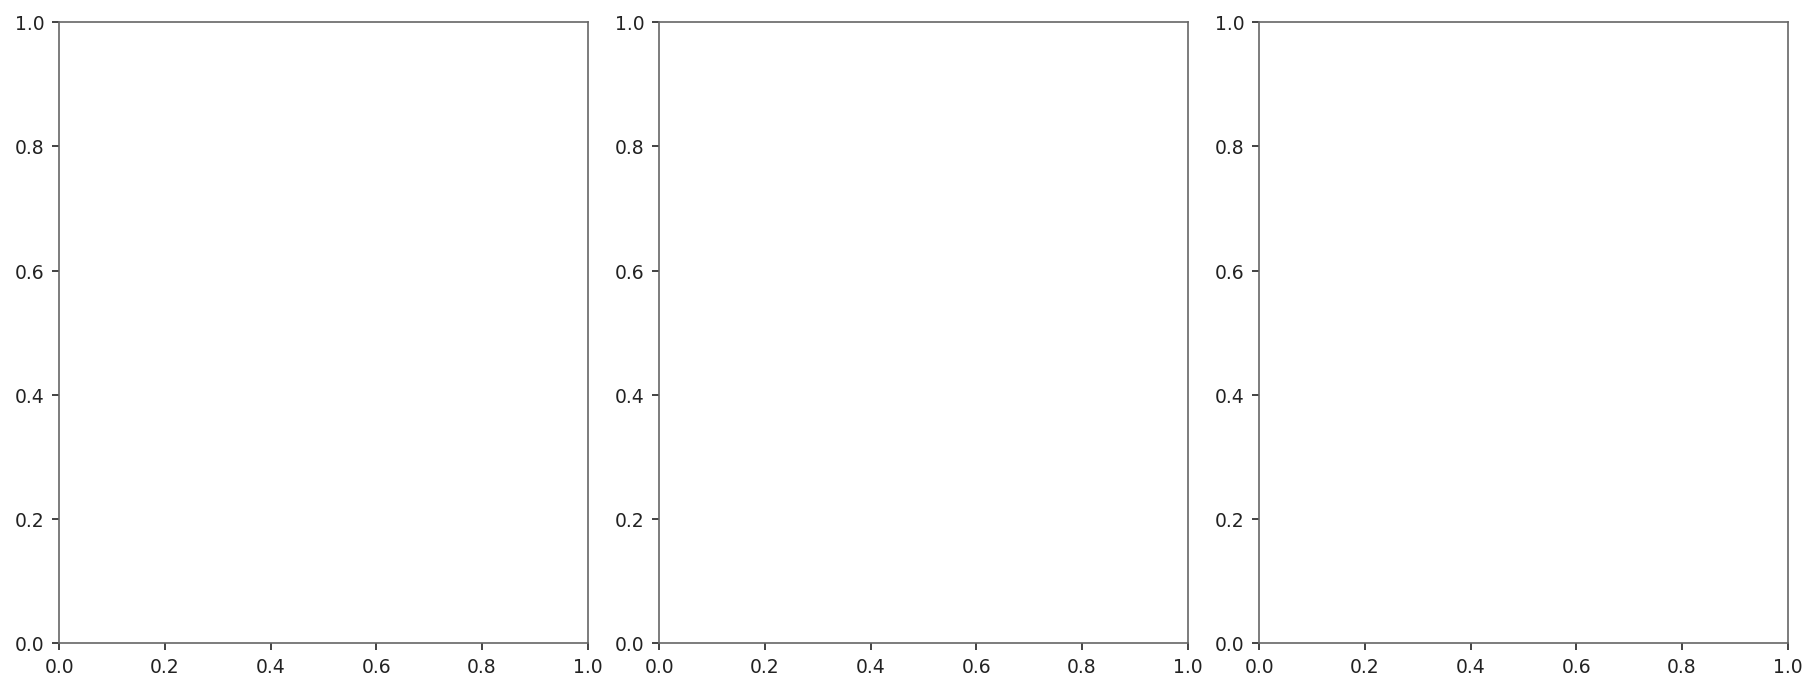

In [18]:

## paper figure 2D pair plots of the 100 validation points inside
## the training cloud, colored by NNdistance to nearest training
## point. Three projections give an unambiguous view without
## matplotlib's 3D occlusion / depthsort issues.

## same palette as generate_workflow_mpl.py / ml_22
ORANGE        = "#E87A00"   ## physics / qubit accent
ORANGE_LIGHT  = "#FFF4E6"
ORANGE_DARK   = "#A85600"
PURPLE        = "#7B68AE"   ## validation / cavity accent
PURPLE_LIGHT  = "#E8E4F0"
PURPLE_DARK   = "#4A3D78"
GREEN         = "#3D8B3D"
GREEN_LIGHT   = "#E8F5E8"
TEXT_MAIN     = "#222222"
TEXT_DIM      = "#555555"

## project palette colormap Green > Purple > Orange
paper_cmap = LinearSegmentedColormap.from_list(
    'paper_GPO', [GREEN, PURPLE, ORANGE], N=256)

plt.rcParams.update({
    "text.usetex":      False,
    "mathtext.fontset": "cm",
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.labelcolor":  TEXT_MAIN,
    "xtick.color":      TEXT_MAIN,
    "ytick.color":      TEXT_MAIN,
    "axes.edgecolor":   "#666666",
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  9,
    "figure.dpi":       150,
})

cont_indices = [j for j in range(len(qiskit_param_names)) if not is_integer_param[j]]
if len(cont_indices) >= 3:
    p0, p1, p2 = cont_indices[0], cont_indices[1], cont_indices[2]
else:
    p0, p1, p2 = 0, 1, 2

short_names = {p: qiskit_param_names[p].replace('design_options.', '')
               for p in (p0, p1, p2)}
pair_indices = [(p0, p1), (p0, p2), (p1, p2)]

## shared color scale across all three panels
vmin, vmax = selected_nn_dist.min(), selected_nn_dist.max()

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), constrained_layout=True)

In [19]:
UM = 1e6  ## meters > micrometers

for ax, (i, j) in zip(axes, pair_indices):
    ax.set_axisbelow(True)

    ## training data in background neutral grey, matching paper style
    ax.scatter(X_train_unscaled[:, i] * UM, X_train_unscaled[:, j] * UM,
               c='#D9D9D9', s=9, alpha=0.6,
               label='Training data', zorder=1, rasterized=True)

    ## validation points colored by NN distance using the project palette colormap
    sc = ax.scatter(selected_params_unscaled[:, i] * UM,
                    selected_params_unscaled[:, j] * UM,
                    c=selected_nn_dist, cmap=paper_cmap,
                    vmin=vmin, vmax=vmax,
                    s=52, marker='D', edgecolors=TEXT_MAIN, linewidths=0.5,
                    label='Validation points', zorder=3)

    ## increase labelpad to avoid any potential overlap
    ax.set_xlabel(f'{short_names[i]} (um)', color=TEXT_MAIN, labelpad=12)
    ax.set_ylabel(f'{short_names[j]} (um)', color=TEXT_MAIN)

    ## dotted light grid same as boxplot / hyperparameter cells in ml_22
    ax.grid(axis='both', linestyle=':', linewidth=0.6, color='#BBBBBB', alpha=0.7)

    ## closed plot box matching paper style (#666666 on all sides)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#666666')
        spine.set_linewidth(1.0)

    ax.tick_params(axis='both', colors=TEXT_MAIN, labelsize=9)

    ## format numbers plainly (e.g. 150) rather than scientific notation
    ## since we already scaled by 1e6 (um). This avoids the offsetText overlap!
    ax.ticklabel_format(axis='both', style='plain')

## legend on the first panel matches ml_22 frameon style
axes[0].legend(loc='lower right', fontsize=8.5,
               frameon=True, fancybox=False,
               edgecolor='#BBBBBB', framealpha=0.95)

## shared colorbar on the right styled to match paper palette
cbar = fig.colorbar(sc, ax=axes, shrink=0.9, aspect=28, pad=0.015)
cbar.set_label('NN distance  (scaled [0,1] param space)',
               fontsize=10, color=TEXT_MAIN)
cbar.ax.tick_params(labelsize=8.5, labelcolor=TEXT_MAIN)
cbar.outline.set_edgecolor('#666666')
cbar.outline.set_linewidth(0.8)

plt.savefig(str(Path(PLOTS_DIR) / 'surrogate_stress_random_points_pairs.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()
print("Saved -> plots/surrogate_stress_random_points_pairs.pdf")

<Figure size 960x720 with 0 Axes>

Saved -> plots/surrogate_stress_random_points_pairs.pdf


# EM simulator results

In [20]:
df = pd.read_csv(str(Path(RESULTS_DIR) / 'validation/best_candidates_for_em_sim_validation-with_EM_sim.csv'))

cap_names = ['cross_to_ground', 'claw_to_ground', 'cross_to_claw',
             'cross_to_cross', 'claw_to_claw', 'ground_to_ground']
eps = 1e-15

## compute % errors EM simulator vs surrogate, and EM simulator vs target
for cap in cap_names:
    df[f'pct_ansys_vs_surrogate_{cap}'] = 100 * abs(df[f'ansys_{cap}'] - df[f'surrogate_pred_{cap}']) / (abs(df[f'ansys_{cap}']) + eps)
    df[f'pct_ansys_vs_target_{cap}'] = 100 * abs(df[f'ansys_{cap}'] - df[f'target_{cap}']) / (abs(df[f'ansys_{cap}']) + eps)

## mean % error across all cap columns per row
df['mean_pct_ansys_vs_surrogate'] = df[[f'pct_ansys_vs_surrogate_{c}' for c in cap_names]].mean(axis=1)
df['mean_pct_ansys_vs_target'] = df[[f'pct_ansys_vs_target_{c}' for c in cap_names]].mean(axis=1)

sigmas = sorted(df['sigma_for_gauss'].unique())

## compute NN distance (scaled [0,1] Euclidean) for every row in the EM simulator df.
## the CSV stores the UNSCALED qiskit params we scale them first using the
## same scalers the surrogate was trained with.
def _match_param_col(df_cols, qname):
    ## prefer exact, then 'param_' prefix, then endswith, then shortname exact
    short = qname.split('.')[-1]
    for cand in (qname, f'param_{qname}'):
        if cand in df_cols:
            return cand
    endings = [c for c in df_cols if c.endswith(qname) or c.endswith('.' + short)]
    if endings:
        return endings[0]
    shorts = [c for c in df_cols if c == short or c == f'param_{short}']
    if shorts:
        return shorts[0]
    return None

df_cols = list(df.columns)
param_order_for_scaling = [_match_param_col(df_cols, name) for name in qiskit_param_names]

if all(c is not None for c in param_order_for_scaling):
    df_params_unscaled = df[param_order_for_scaling].to_numpy(dtype='float64')
    df_params_scaled = scale_qiskit(df_params_unscaled)
    df['nn_dist'] = nearest_train_distance(df_params_scaled)
    print(f'Matched param columns in CSV: {param_order_for_scaling}')
else:
    print('WARNING: could not match all param_cols in CSV to qiskit_param_names.')
    print(f'  qiskit_param_names = {qiskit_param_names}')
    print(f'  df columns containing "param": {[c for c in df_cols if "param" in c.lower() or any(q.split(".")[-1] in c for q in qiskit_param_names)]}')
    df['nn_dist'] = np.nan

print(f'EM simulator-df nn_dist:  min={df["nn_dist"].min():.4f}  '
      f'median={df["nn_dist"].median():.4f}  max={df["nn_dist"].max():.4f}')

Matched param columns in CSV: ['param_connection_pads.readout.claw_length', 'param_connection_pads.readout.ground_spacing', 'param_cross_length']
EM simulator-df nn_dist:  min=0.0254  median=0.0308  max=0.1793


/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/olivias/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [21]:

JSON_PATH = str(Path(RESULTS_DIR) / "validation/random_candidates_tested_with_em_sim_nn_bins.json")

ORANGE       = "#E87A00";  ORANGE_LIGHT = "#FFF4E6"
PURPLE       = "#7B68AE";  PURPLE_LIGHT = "#E8E4F0"
GREEN        = "#3D8B3D";  GREEN_LIGHT  = "#E8F5E8"
TEXT_MAIN    = "#222222"

plt.rcParams.update({
    "text.usetex": False, "mathtext.fontset": "cm",
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "axes.labelcolor": TEXT_MAIN, "xtick.color": TEXT_MAIN, "ytick.color": TEXT_MAIN,
    "axes.edgecolor": "#666666", "axes.labelsize": 13, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10, "figure.dpi": 150,
})

## load data
with open(JSON_PATH) as f:
    data = json.load(f)

## organize perbin arrays
bins = sorted(set(int(d['nn_bin']) for d in data))
fq_by_bin, ah_by_bin, nn_by_bin = {}, {}, {}
eps = 1e-15
for b in bins:
    rows = [d for d in data if int(d['nn_bin']) == b]
    fq_by_bin[b] = np.array([
        100 - 100 * abs(d['pred_H_params']['qubit_frequency_GHz']
                        - d['surrogate_H_params']['qubit_frequency_GHz'])
              / (abs(d['pred_H_params']['qubit_frequency_GHz']) + eps)
        for d in rows])
    ah_by_bin[b] = np.array([
        100 - 100 * abs(d['pred_H_params']['anharmonicity_MHz']
                        - d['surrogate_H_params']['anharmonicity_MHz'])
              / (abs(d['pred_H_params']['anharmonicity_MHz']) + eps)
        for d in rows])
    ## geometry similarity 100 (nn_distance_scaled * 100)
    nn_by_bin[b] = np.array([100 - d['nn_distance_scaled'] * 100 for d in rows])

## perbin statistics
bin_labels = []
raw_nn_mean = [np.mean([d['nn_distance_scaled'] for d in data if int(d['nn_bin']) == b])
               for b in bins]

fq_med, fq_q1, fq_q3 = [], [], []
ah_med, ah_q1, ah_q3 = [], [], []
nn_med, nn_q1, nn_q3 = [], [], []
fq_pts, ah_pts = [], []

for i, b in enumerate(bins):
    fq = fq_by_bin[b];  ah = ah_by_bin[b];  nn = nn_by_bin[b]
    bin_labels.append(f"{raw_nn_mean[i]:.3f}")

    fq_med.append(np.median(fq));  fq_q1.append(np.percentile(fq, 25));  fq_q3.append(np.percentile(fq, 75))
    ah_med.append(np.median(ah));  ah_q1.append(np.percentile(ah, 25));  ah_q3.append(np.percentile(ah, 75))
    nn_med.append(np.median(nn));  nn_q1.append(np.percentile(nn, 25));  nn_q3.append(np.percentile(nn, 75))
    fq_pts.append(fq);  ah_pts.append(ah)

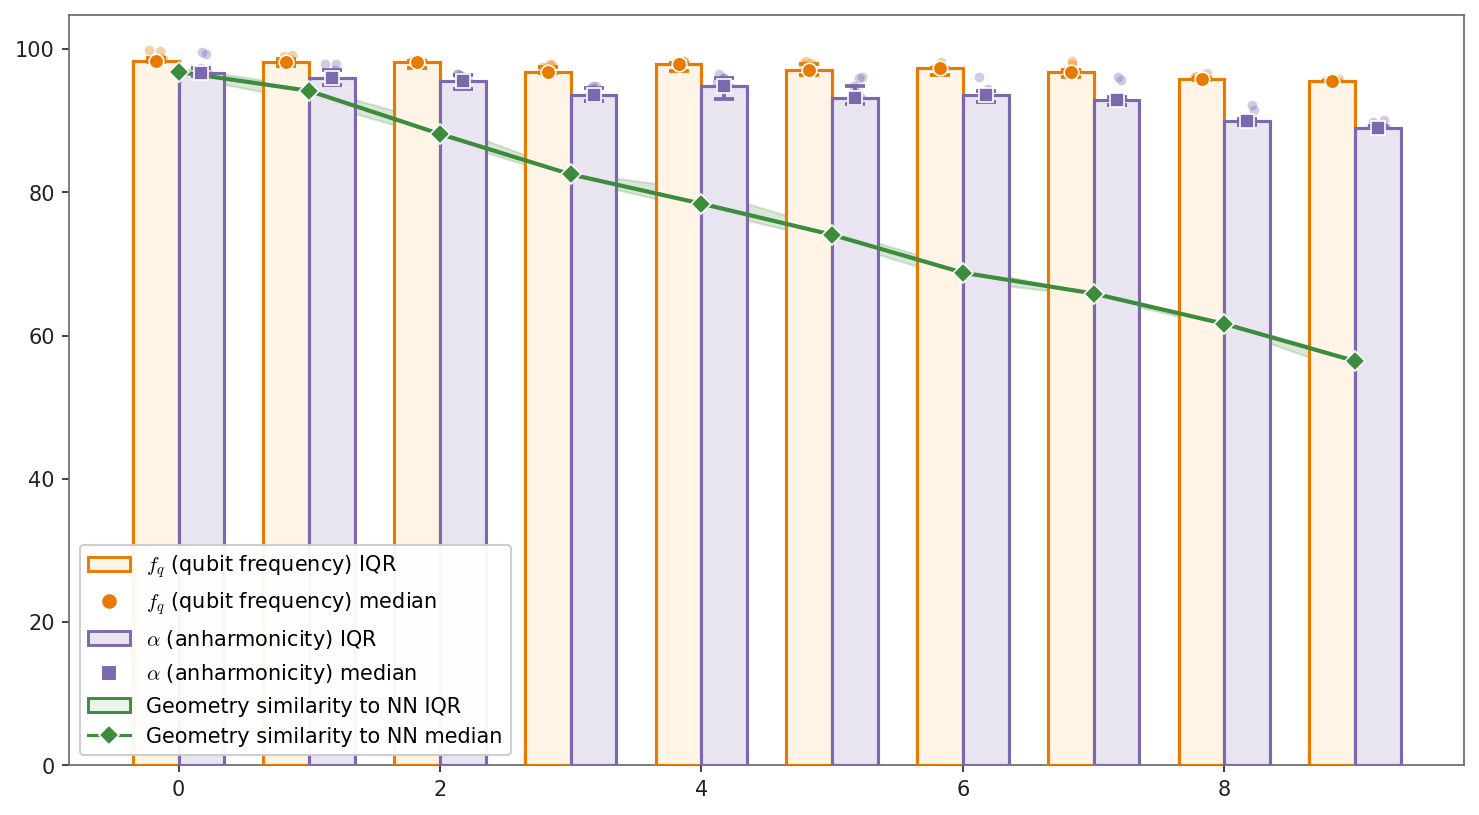

In [22]:
fq_med = np.array(fq_med);  fq_q1 = np.array(fq_q1);  fq_q3 = np.array(fq_q3)
ah_med = np.array(ah_med);  ah_q1 = np.array(ah_q1);  ah_q3 = np.array(ah_q3)
nn_med = np.array(nn_med);  nn_q1 = np.array(nn_q1);  nn_q3 = np.array(nn_q3)

n          = len(bins)
x          = np.arange(n)
width      = 0.35
jitter_amp = 0.06

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

## raw scatter points
rng = np.random.default_rng(42)
for i in range(n):
    j_fq = rng.uniform(-jitter_amp, jitter_amp, size=len(fq_pts[i]))
    j_ah = rng.uniform(-jitter_amp, jitter_amp, size=len(ah_pts[i]))
    ax.scatter(x[i] - width/2 + j_fq, fq_pts[i],
               color=ORANGE, alpha=0.35, s=22, zorder=2, linewidths=0)
    ax.scatter(x[i] + width/2 + j_ah, ah_pts[i],
               color=PURPLE, alpha=0.35, s=22, zorder=2, linewidths=0)

## histogram bars (median height)
ax.bar(x - width/2, fq_med, width=width,
       color=ORANGE_LIGHT, edgecolor=ORANGE, linewidth=1.5, zorder=3)
ax.bar(x + width/2, ah_med, width=width,
       color=PURPLE_LIGHT, edgecolor=PURPLE, linewidth=1.5, zorder=3)

## iqr error bars
ax.errorbar(x - width/2, fq_med, yerr=[fq_med - fq_q1, fq_q3 - fq_med],
            fmt='none', ecolor=ORANGE, elinewidth=1.8, capsize=5, capthick=1.8, zorder=5)
ax.errorbar(x + width/2, ah_med, yerr=[ah_med - ah_q1, ah_q3 - ah_med],
            fmt='none', ecolor=PURPLE, elinewidth=1.8, capsize=5, capthick=1.8, zorder=5)

## median markers
ax.plot(x - width/2, fq_med, 'o', color=ORANGE, ms=7, zorder=6,
        markeredgecolor="white", markeredgewidth=0.8)
ax.plot(x + width/2, ah_med, 's', color=PURPLE, ms=7, zorder=6,
        markeredgecolor="white", markeredgewidth=0.8)

## green geometry similarity line same axis, no twinx
ax.fill_between(x, nn_q1, nn_q3, color=GREEN, alpha=0.20, zorder=1)
ax.plot(x, nn_med, color=GREEN, linewidth=2.0, zorder=4)
ax.plot(x, nn_med, 'D', color=GREEN, ms=7, zorder=6,
        markeredgecolor="white", markeredgewidth=0.8)

legend_handles = [
    mpatches.Patch(facecolor=ORANGE_LIGHT, edgecolor=ORANGE, linewidth=1.4,
                   label=r"$f_q$ (qubit frequency) IQR"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=ORANGE,
               markersize=8, label=r"$f_q$ (qubit frequency) median"),
    mpatches.Patch(facecolor=PURPLE_LIGHT, edgecolor=PURPLE, linewidth=1.4,
                   label=r"$\alpha$ (anharmonicity) IQR"),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=PURPLE,
               markersize=8, label=r"$\alpha$ (anharmonicity) median"),
    mpatches.Patch(facecolor=GREEN_LIGHT, edgecolor=GREEN, linewidth=1.4,
                   label="Geometry similarity to NN IQR"),
    plt.Line2D([0], [0], marker='D', color=GREEN, markerfacecolor=GREEN,
               markersize=7, markeredgecolor="white", markeredgewidth=0.8,
               label="Geometry similarity to NN median"),
]
ax.legend(handles=legend_handles, frameon=True, framealpha=0.95,
          edgecolor="#cccccc", loc="lower left")

In [23]:
## axes styling
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=0)
ax.set_xlabel("Scaled [0,1] Euclidean distance to Nearest Neighbor", labelpad=8)
ax.set_ylabel("Accuracy / Similarity (%)", labelpad=8)
ax.set_title("EM simulator vs Surrogate Prediction accuracy of Hamiltonian parameters",
             fontsize=14, pad=12)
ax.set_ylim(0, 100)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#666666')
    spine.set_linewidth(1.0)
ax.tick_params(axis='both', which='both', length=4, color='#888888')
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
os.makedirs(PLOTS_DIR, exist_ok=True)
plt.savefig(str(Path(PLOTS_DIR) / 'em_sim_validation_error_vs_nn_distance.pdf'), bbox_inches='tight')
plt.show()

<Figure size 960x720 with 0 Axes>

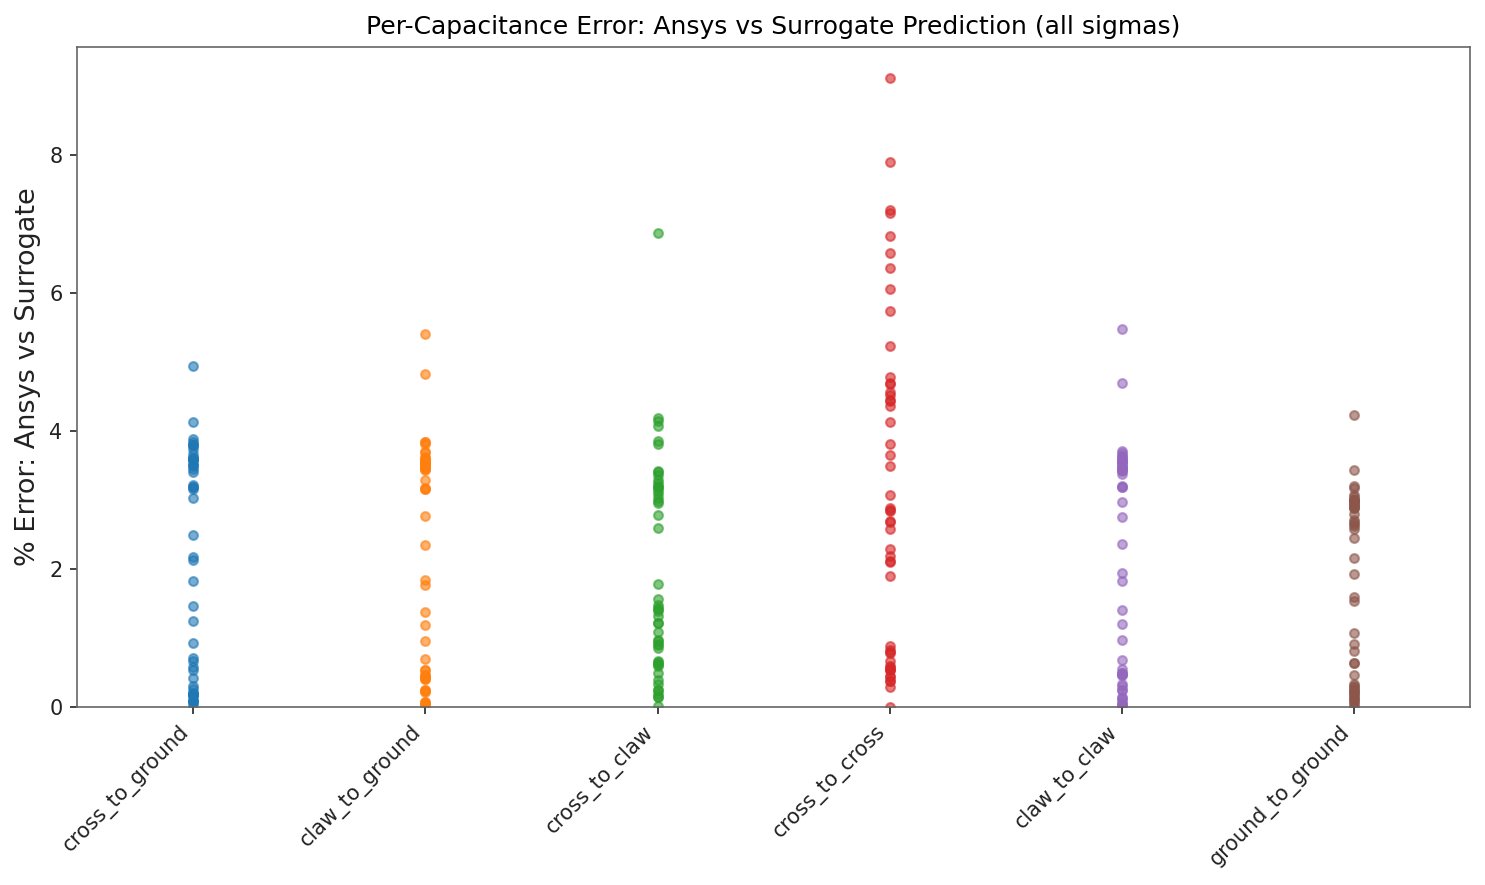

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
for j, cap in enumerate(cap_names):
    col = f'pct_ansys_vs_surrogate_{cap}'
    vals = df[col].values
    ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.6)
ax.set_xticks(range(len(cap_names)))
ax.set_xticklabels(cap_names, rotation=45, ha='right')
ax.set_ylabel('% Error: EM simulator vs Surrogate')
ax.set_title('Per-Capacitance Error: EM simulator vs Surrogate Prediction (all sigmas)')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, len(cap_names) - 0.5)
plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'em_sim_vs_surrogate_per_cap.pdf'))
plt.show()

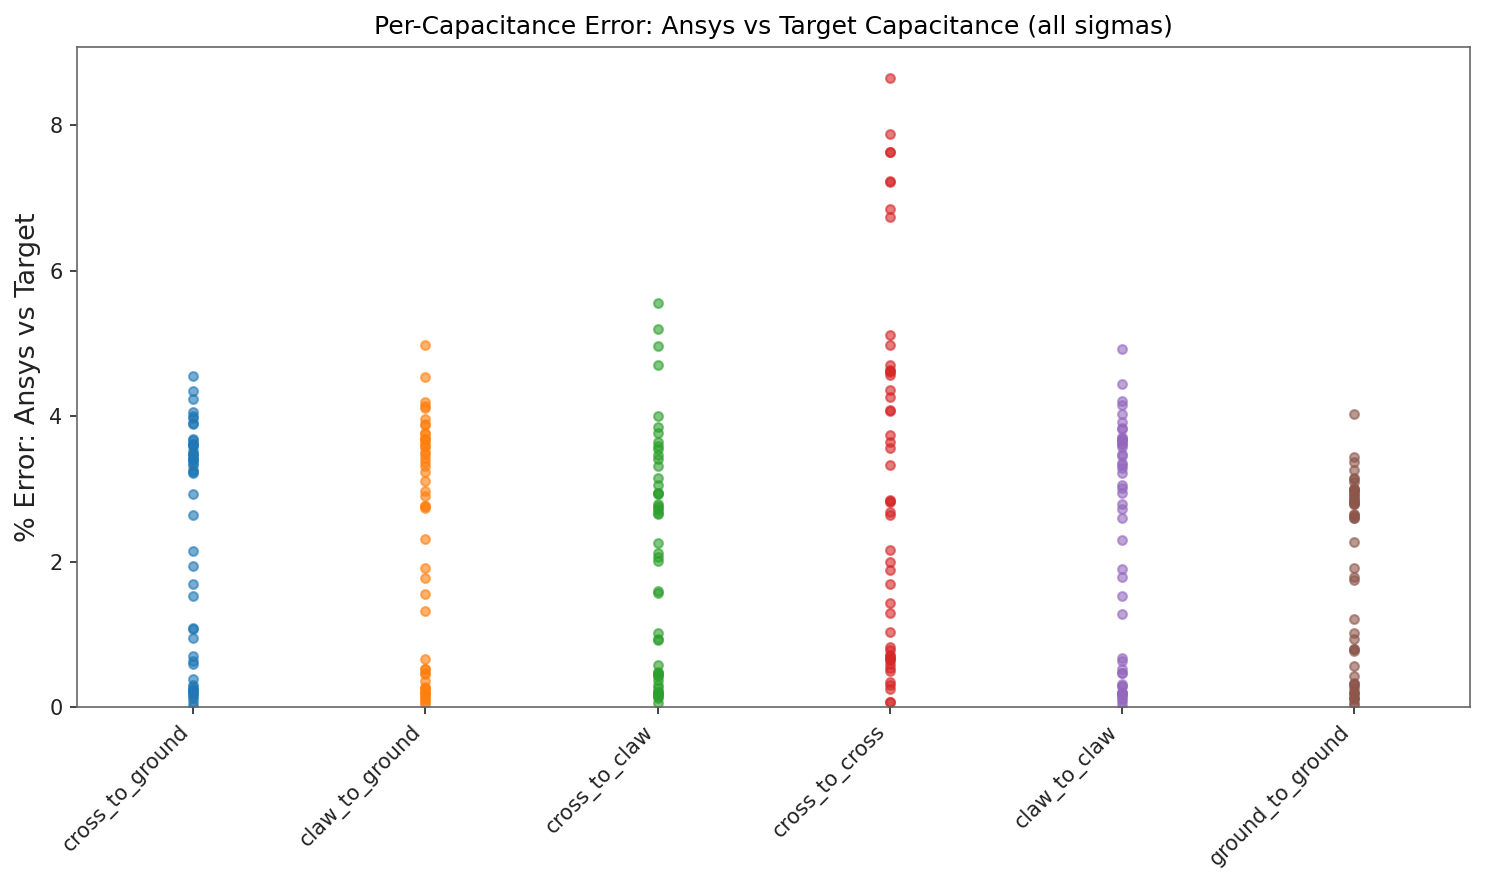

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
for j, cap in enumerate(cap_names):
    col = f'pct_ansys_vs_target_{cap}'
    vals = df[col].values
    ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.6)
ax.set_xticks(range(len(cap_names)))
ax.set_xticklabels(cap_names, rotation=45, ha='right')
ax.set_ylabel('% Error: EM simulator vs Target')
ax.set_title('Per-Capacitance Error: EM simulator vs Target Capacitance (all sigmas)')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, len(cap_names) - 0.5)
plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'em_sim_vs_target_per_cap.pdf'))
plt.show()

/tmp/ipykernel_1636/2418720333.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(_split_by_qbin('mean_pct_em_sim_vs_surrogate'),
/tmp/ipykernel_1636/2418720333.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(_split_by_qbin('mean_pct_em_sim_vs_target'),


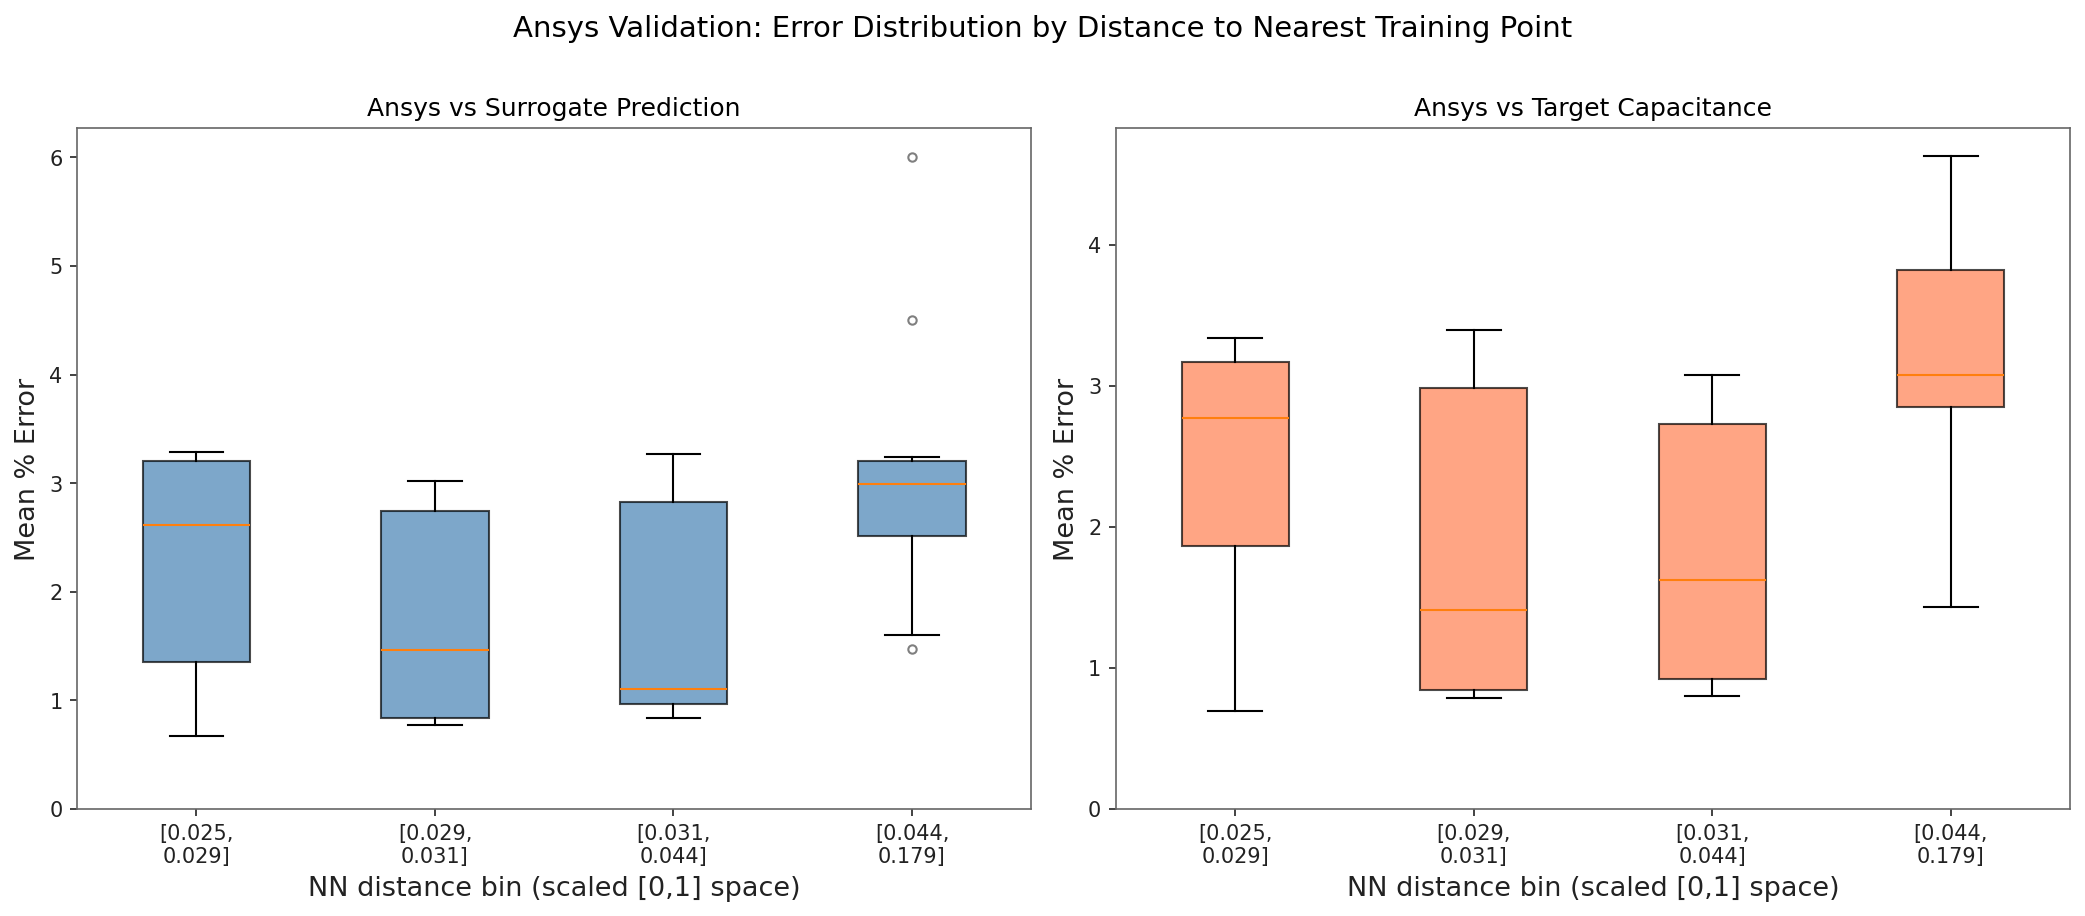

In [26]:
## boxplots of EM simulator error, binned by distance to the nearest training point
## (scaled [0,1] Euclidean). Using 4 quantile bins so each box has a similar
## sample count regardless of how the sigmas populate the distance axis.

n_qbins = 4
q_edges = np.quantile(df['nn_dist'].to_numpy(), np.linspace(0, 1, n_qbins + 1))
bin_labels = [f'[{q_edges[k]:.3f},\n{q_edges[k+1]:.3f}]' for k in range(n_qbins)]

def _split_by_qbin(col):
    out = []
    nn = df['nn_dist'].to_numpy()
    for k in range(n_qbins):
        lo, hi = q_edges[k], q_edges[k + 1]
        in_bin = (nn >= lo) & (nn <= hi if k == n_qbins - 1 else nn < hi)
        out.append(df[col].to_numpy()[in_bin])
    return out

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

## EM simulator vs Surrogate
bp1 = ax1.boxplot(_split_by_qbin('mean_pct_ansys_vs_surrogate'),
                  labels=bin_labels, patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax1.set_xlabel('NN distance bin (scaled [0,1] space)')
ax1.set_ylabel('Mean % Error')
ax1.set_title('EM simulator vs Surrogate Prediction')
ax1.set_ylim(0, None)

## EM simulator vs Target
bp2 = ax2.boxplot(_split_by_qbin('mean_pct_ansys_vs_target'),
                  labels=bin_labels, patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp2['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
ax2.set_xlabel('NN distance bin (scaled [0,1] space)')
ax2.set_ylabel('Mean % Error')
ax2.set_title('EM simulator vs Target Capacitance')
ax2.set_ylim(0, None)

fig.suptitle('EM simulator Validation: Error Distribution by Distance to Nearest Training Point',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'em_sim_validation_boxplots_by_nn_distance.pdf'))
plt.show()

In [27]:
## stats table grouped by NNdistance quantile (same 4 bins as the boxplots).

n_qbins = 4
q_edges = np.quantile(df['nn_dist'].to_numpy(), np.linspace(0, 1, n_qbins + 1))

def _bin_mask(k):
    nn = df['nn_dist'].to_numpy()
    lo, hi = q_edges[k], q_edges[k + 1]
    return (nn >= lo) & (nn <= hi if k == n_qbins - 1 else nn < hi)

for title, col in [
    ('EM simulator vs Surrogate Prediction', 'mean_pct_ansys_vs_surrogate'),
    ('EM simulator vs Target Capacitance',   'mean_pct_ansys_vs_target'),
]:
    print(title)
    print(f'{"NN dist bin":>22s} {"N":>5s} {"Median %":>10s} {"Mean %":>10s} {"Max %":>10s}')
    print('-' * 62)
    for k in range(n_qbins):
        m = _bin_mask(k)
        vals = df.loc[m, col]
        label = f'[{q_edges[k]:.3f}, {q_edges[k+1]:.3f}]'
        if len(vals) == 0:
            print(f'{label:>22s} {0:5d}  (empty)')
            continue
        print(f'{label:>22s} {len(vals):5d} {vals.median():10.2f} {vals.mean():10.2f} {vals.max():10.2f}')
    print()

EM simulator vs Surrogate Prediction
           NN dist bin     N   Median %     Mean %      Max %
--------------------------------------------------------------
        [0.025, 0.029]    13       2.62       2.31       3.29
        [0.029, 0.031]    12       1.46       1.70       3.02
        [0.031, 0.044]    12       1.11       1.79       3.27
        [0.044, 0.179]    13       2.99       3.04       6.00

EM simulator vs Target Capacitance
           NN dist bin     N   Median %     Mean %      Max %
--------------------------------------------------------------
        [0.025, 0.029]    13       2.77       2.41       3.34
        [0.029, 0.031]    12       1.41       1.89       3.40
        [0.031, 0.044]    12       1.62       1.84       3.08
        [0.044, 0.179]    13       3.08       3.10       4.63



/tmp/ipykernel_1636/2418720333.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(_split_by_qbin('mean_pct_em_sim_vs_surrogate'),
/tmp/ipykernel_1636/2418720333.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(_split_by_qbin('mean_pct_em_sim_vs_target'),


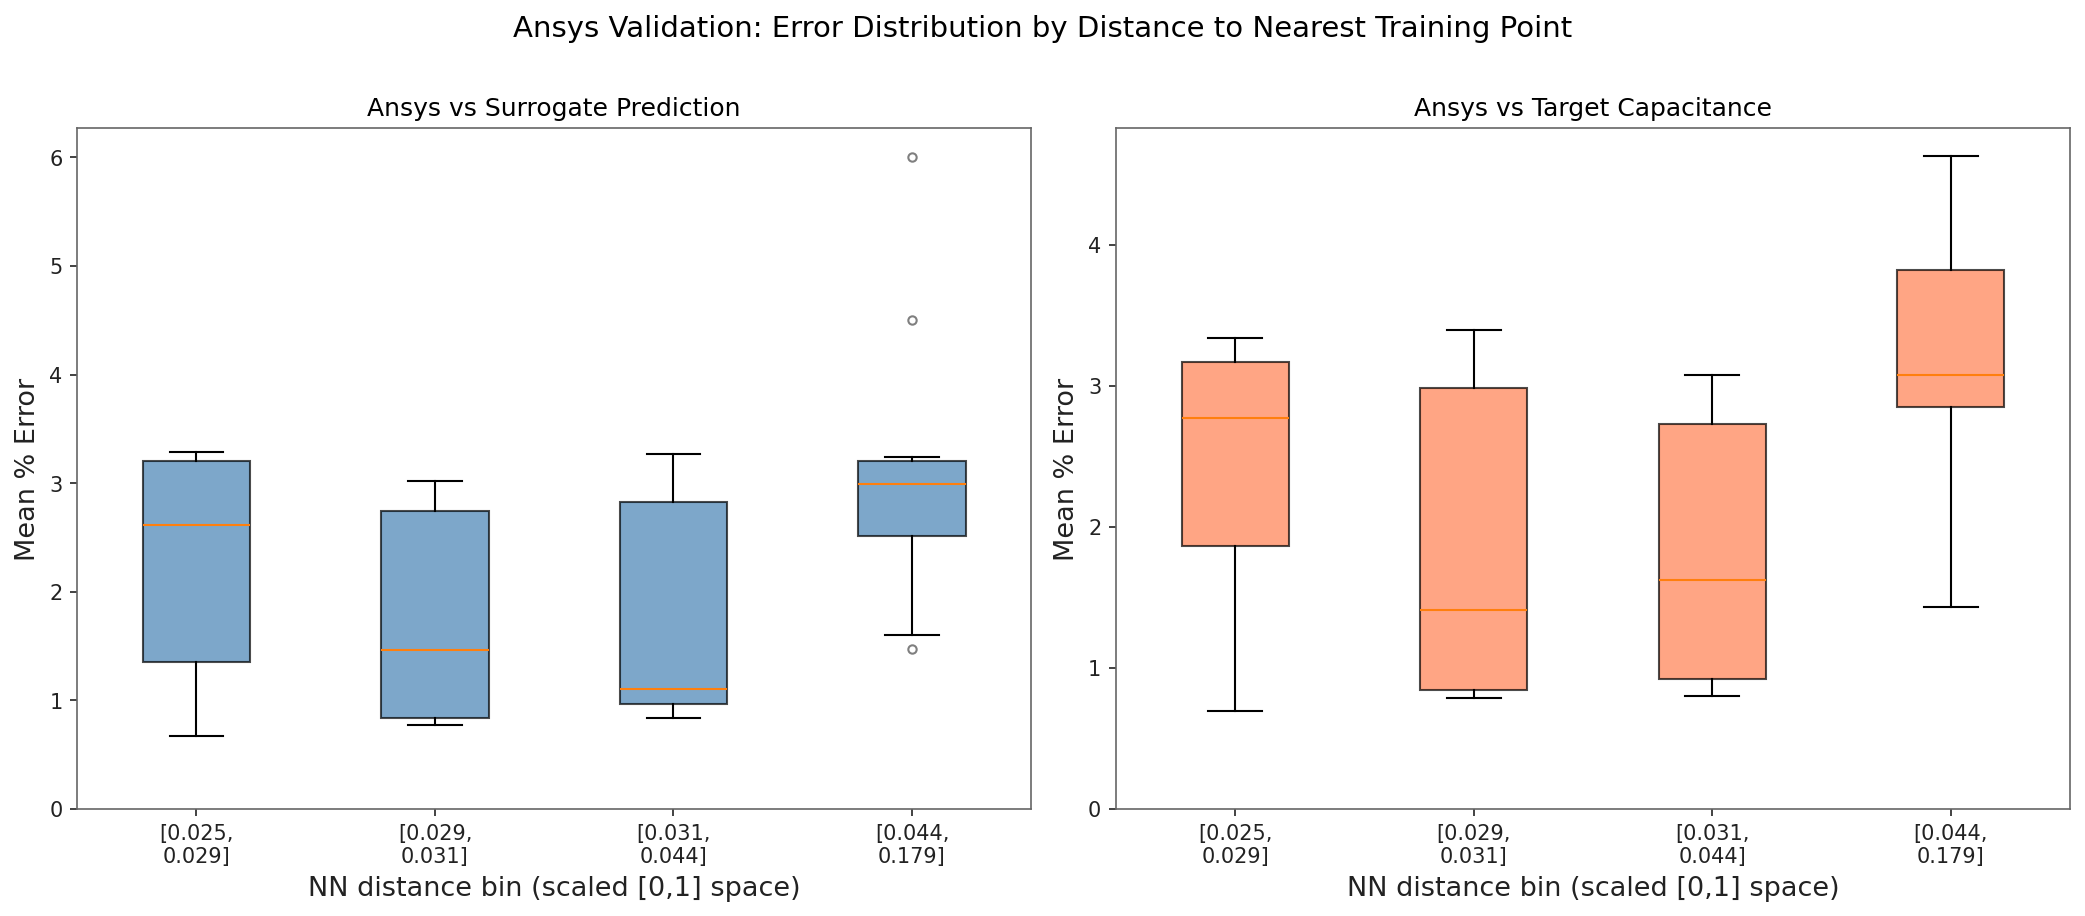

In [28]:
## boxplots of EM simulator error, binned by distance to the nearest training point
## (scaled [0,1] Euclidean). Using 4 quantile bins so each box has a similar
## sample count regardless of how the sigmas populate the distance axis.

n_qbins = 4
q_edges = np.quantile(df['nn_dist'].to_numpy(), np.linspace(0, 1, n_qbins + 1))
bin_labels = [f'[{q_edges[k]:.3f},\n{q_edges[k+1]:.3f}]' for k in range(n_qbins)]

def _split_by_qbin(col):
    out = []
    nn = df['nn_dist'].to_numpy()
    for k in range(n_qbins):
        lo, hi = q_edges[k], q_edges[k + 1]
        in_bin = (nn >= lo) & (nn <= hi if k == n_qbins - 1 else nn < hi)
        out.append(df[col].to_numpy()[in_bin])
    return out

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

## EM simulator vs Surrogate
bp1 = ax1.boxplot(_split_by_qbin('mean_pct_ansys_vs_surrogate'),
                  labels=bin_labels, patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp1['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax1.set_xlabel('NN distance bin (scaled [0,1] space)')
ax1.set_ylabel('Mean % Error')
ax1.set_title('EM simulator vs Surrogate Prediction')
ax1.set_ylim(0, None)

## EM simulator vs Target
bp2 = ax2.boxplot(_split_by_qbin('mean_pct_ansys_vs_target'),
                  labels=bin_labels, patch_artist=True,
                  flierprops=dict(marker='o', markersize=4, alpha=0.5))
for patch in bp2['boxes']:
    patch.set_facecolor('coral')
    patch.set_alpha(0.7)
ax2.set_xlabel('NN distance bin (scaled [0,1] space)')
ax2.set_ylabel('Mean % Error')
ax2.set_title('EM simulator vs Target Capacitance')
ax2.set_ylim(0, None)

fig.suptitle('EM simulator Validation: Error Distribution by Distance to Nearest Training Point',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'em_sim_validation_boxplots_by_nn_distance.pdf'))
plt.show()

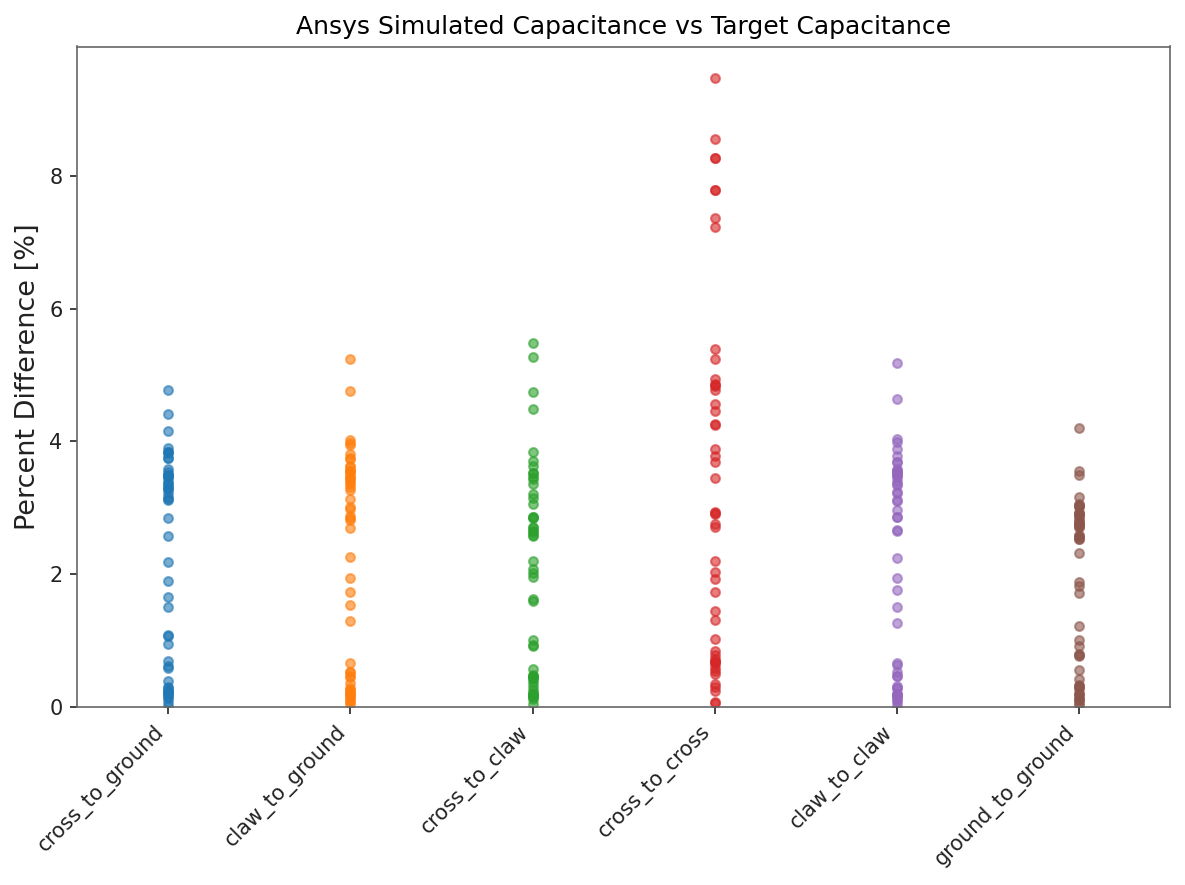

Cap Column                  Median %     Mean %      Max %
-------------------------------------------------------
cross_to_ground                 3.13       2.27       4.78
claw_to_ground                  2.86       2.25       5.25
cross_to_claw                   2.14       2.04       5.49
cross_to_cross                  2.91       3.31       9.47
claw_to_claw                    2.86       2.23       5.19
ground_to_ground                2.54       1.85       4.20
-------------------------------------------------------
All (avg per sample)            2.62       2.33       4.91


In [29]:
df = pd.read_csv(str(Path(RESULTS_DIR) / 'validation/best_candidates_for_em_sim_validation-with_EM_sim.csv'))

cap_names = ['cross_to_ground', 'claw_to_ground', 'cross_to_claw',
             'cross_to_cross', 'claw_to_claw', 'ground_to_ground']
eps = 1e-15

## percent error EM simulator result vs what we were aiming for (target from test set)
for cap in cap_names:
    df[f'pct_err_{cap}'] = 100 * abs(df[f'ansys_{cap}'] - df[f'target_{cap}']) / (abs(df[f'target_{cap}']) + eps)

df['mean_pct_err'] = df[[f'pct_err_{c}' for c in cap_names]].mean(axis=1)
sigmas = sorted(df['sigma_for_gauss'].unique())

## scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
for j, cap in enumerate(cap_names):
    vals = df[f'pct_err_{cap}'].values
    ax.scatter(np.full(len(vals), j), vals, s=18, alpha=0.6)
ax.set_xticks(range(len(cap_names)))
ax.set_xticklabels(cap_names, rotation=45, ha='right')
ax.set_ylabel('Percent Difference [%]')
ax.set_title('EM simulator Simulated Capacitance vs Target Capacitance')
ax.set_ylim(0, None)
ax.margins(y=0)
ax.set_xlim(-0.5, len(cap_names) - 0.5)
plt.tight_layout()
plt.savefig(str(Path(PLOTS_DIR) / 'em_sim_vs_target_scatter.pdf'))
plt.show()

print(f'{"Cap Column":<25s} {"Median %":>10s} {"Mean %":>10s} {"Max %":>10s}')
print('-' * 55)
for cap in cap_names:
    vals = df[f'pct_err_{cap}']
    print(f'{cap:<25s} {vals.median():10.2f} {vals.mean():10.2f} {vals.max():10.2f}')
print('-' * 55)
all_vals = df['mean_pct_err']
print(f'{"All (avg per sample)":<25s} {all_vals.median():10.2f} {all_vals.mean():10.2f} {all_vals.max():10.2f}')

In [30]:
## ratio how much error does the surrogate ADD vs the natural physical variation?
for cap in cap_names:
    df[f'ratio_{cap}'] = abs(df[f'ansys_{cap}'] - df[f'surrogate_pred_{cap}']) / (abs(df[f'ansys_{cap}'] - df[f'target_{cap}']) + eps)

df['mean_ratio'] = df[[f'ratio_{c}' for c in cap_names]].mean(axis=1)

print('Ratio of surrogate error to physical variation (lower = surrogate adds less noise):')
print(f'{"Sigma %":>10s} {"Median":>10s} {"Mean":>10s}')
print('-' * 35)
for s in sigmas:
    sub = df[df['sigma_for_gauss'] == s]['mean_ratio']
    print(f'{s:10d} {sub.median():10.3f} {sub.mean():10.3f}')

Ratio of surrogate error to physical variation (lower = surrogate adds less noise):
   Sigma %     Median       Mean
-----------------------------------
         1      0.949      1.161
         2      0.959      0.948
         5      1.005      1.045
        10      1.081      1.319
        20      0.980      1.100
